# Lab 21 — LoRA / QLoRA Fine-tuning · **T4 / Free Colab Edition**

**AICB-P2T3 · Ngày 21 · Chương 5 — Fine-tuning & An Toàn**

Mục tiêu:
- Hoàn thành đầy đủ core lab với `r=8`, `r=16`, `r=64`
- Sinh đủ artifact cho `REPORT.md`
- Hỗ trợ luôn các **stretch goals** để tối đa hóa bonus: `target ALL layers`, `DoRA`, `Option B / HF Hub`, `W&B`, và optional `GGUF export`

---

## ⚙️ Profile: `T4`

| Setting | Giá trị |
|---|---|
| Model | `unsloth/Qwen2.5-3B-bnb-4bit` |
| Recommended GPU | T4 (16 GB) |
| Train batch / eval batch | 1 / 1 |
| Gradient accumulation | 8 (effective batch = 8) |
| Eval strategy | `"no"` during training |
| Max seq length cap | 1024 |
| Dataset samples | 200 by default |
| Stretch goals | configurable via flags below |



## 0. Setup & Environment Check

In [1]:
# Shared imports used throughout the notebook (safe to run anywhere)
import os
import time
import gc
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
# Configure matplotlib for notebooks
plt.rcParams['figure.figsize'] = (8, 4)
# Helpful defaults
np.random.seed(42)
torch.manual_seed(42)
gc.collect()
print("✓ Core imports ready")

✓ Core imports ready


In [ ]:
# 0) Check GPU
!nvidia-smi

# 1) Install Unsloth stack for Kaggle
!pip install --upgrade pip
!pip install --no-cache-dir --upgrade unsloth unsloth_zoo

# 2) Restart kernel after install
import os
os.kill(os.getpid(), 9)

Thu May  7 07:56:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Unsloth must be imported first
import unsloth
from unsloth import FastLanguageModel

import torch
import transformers
import datasets
import trl
import peft
import accelerate
import bitsandbytes as bnb

print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("trl:", trl.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)
print("bnb:", bnb.__version__)
print("OK")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
torch: 2.10.0+cu128
cuda: 12.8
cuda available: True
gpu: Tesla T4
transformers: 5.5.0
datasets: 4.3.0
trl: 0.24.0
peft: 0.18.1
accelerate: 1.12.0
bnb: 0.49.2
OK


In [2]:
import torch
assert torch.cuda.is_available(), "❌ GPU runtime cần được bật. Runtime > Change runtime type > GPU"
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✓ GPU: {name}")
print(f"✓ VRAM: {vram_gb:.1f} GB")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")

if vram_gb > 20:
    print("\n⚠️  Bạn có GPU lớn (>20GB VRAM). Nên dùng phiên bản BigGPU thay vì T4 này — sẽ nhanh hơn nhiều!")
elif 'T4' not in name:
    print(f"\n💡 Notebook này tối ưu cho T4 (16GB). GPU của bạn ({name}) có thể chạy được nhưng underutilized.")

✓ GPU: Tesla T4
✓ VRAM: 15.6 GB
✓ CUDA: 12.8
✓ PyTorch: 2.10.0+cu128


In [3]:
# Create output directories
import os

OUTPUT_DIR = "./outputs"
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
ADAPTERS_DIR = os.path.join(OUTPUT_DIR, "adapters")

for path in [OUTPUT_DIR, RESULTS_DIR, ADAPTERS_DIR]:
    os.makedirs(path, exist_ok=True)

print(f"✓ Output dir: {OUTPUT_DIR}")
print(f"✓ Results dir: {RESULTS_DIR}")
print(f"✓ Adapters dir: {ADAPTERS_DIR}")


✓ Output dir: ./outputs
✓ Results dir: ./outputs/results
✓ Adapters dir: ./outputs/adapters


### External resources required

- Internet access to download the base model and the default public dataset from HuggingFace.
- A CUDA GPU runtime (T4 16 GB is the target profile for this notebook).
- Optional: a HuggingFace token only if you want to push your adapter to the Hub in the final optional step.

This notebook is designed to run end-to-end with the default public dataset, so login is not required for the main lab workflow.


## 1. Dataset Preparation

Mục tiêu: chuẩn bị 100–500 examples Alpaca format. Có 2 lựa chọn:

**A. Dùng dataset có sẵn** — load Vietnamese instruction dataset từ HuggingFace.  
**B. Dùng dataset của bạn** — uncomment cell B và paste data.


In [36]:
# Option A: load a public Vietnamese Alpaca-style dataset from HuggingFace
from datasets import load_dataset

DATASET_ID = "5CD-AI/Vietnamese-alpaca-gpt4-gg-translated"
DATASET_SPLIT = "train"
NUM_SAMPLES = 200  # rubric target: keep your experiment in the 100-500 example range

raw = load_dataset(DATASET_ID, split=DATASET_SPLIT)
raw = raw.shuffle(seed=42)
num_samples = min(NUM_SAMPLES, len(raw))
raw = raw.select(range(num_samples))

print(f"✓ Dataset: {DATASET_ID} [{DATASET_SPLIT}]")
print(f"✓ Loaded {len(raw)} samples")
print(f"✓ Columns: {raw.column_names}")
print("\n--- Sample 0 ---")
print(raw[0])


✓ Dataset: 5CD-AI/Vietnamese-alpaca-gpt4-gg-translated [train]
✓ Loaded 200 samples
✓ Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']

--- Sample 0 ---
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.', 'output_vi': 'Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhậ

In [37]:
# Auto-detect column names — dataset 5CD-AI uses _vi suffix
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output trong: {cols}"
print(f"✓ Cột dùng: instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    inp = example.get(INPUT_COL, "") if INPUT_COL else ""
    inp = inp or ""
    if inp.strip():
        text = ALPACA_TEMPLATE.format(
            instruction=example[INSTRUCTION_COL], input=inp,
            output=example[OUTPUT_COL])
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(
            instruction=example[INSTRUCTION_COL],
            output=example[OUTPUT_COL])
    return {"text": text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print("\n--- Formatted sample ---")
print(ds[0]["text"][:500])

✓ Cột dùng: instruction='instruction_vi', input='input_vi', output='output_vi'

--- Formatted sample ---
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $20


✓ MODEL_NAME = unsloth/Qwen2.5-3B-bnb-4bit
✓ Cleaned dataset: 200 -> 193 samples
Token length distribution:
  min=28, max=738
  p50=231, p95=562, p99=706

✓ Chọn max_seq_length = 1024 (p95 rounded up, cap = 1024)


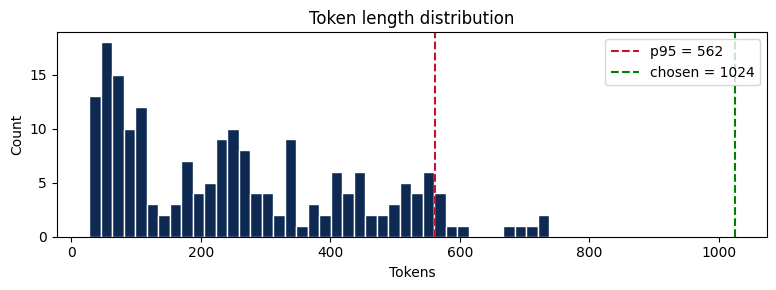

In [38]:
# Clean dataset + token length analysis -> choose max_seq_length = p95 rounded up to power of 2
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Qwen2.5-3B-bnb-4bit"  # tested T4 default from README
MAX_SEQ_CAP = 1024  # hard cap for T4 profile

print(f"✓ MODEL_NAME = {MODEL_NAME}")
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

# Rebuild ds safely if the previous formatting cell removed original output columns
def _extract_output_text(example):
    value = example.get("output_text", "")
    return (value or "").strip()

# If output_text does not exist yet, fall back to parsing from formatted text
if "output_text" not in ds.column_names:
    def recover_output_text(example):
        text = example["text"]
        if "### Response:" in text:
            output_text = text.split("### Response:", 1)[-1].strip()
        else:
            output_text = text.strip()
        return {"output_text": output_text}
    ds = ds.map(recover_output_text)

def has_long_output(example):
    output_text = _extract_output_text(example)
    return len(tok.encode(output_text, add_special_tokens=False)) >= 10

before_clean = len(ds)
ds = ds.filter(has_long_output)

if len(ds) > 0 and len(ds) <= 5000:
    df = ds.to_pandas().drop_duplicates(subset=["text"]).reset_index(drop=True)
    ds = Dataset.from_pandas(df, preserve_index=False)

after_clean = len(ds)
print(f"✓ Cleaned dataset: {before_clean} -> {after_clean} samples")

if after_clean == 0:
    raise ValueError(
        "Dataset became empty after cleaning. This usually means the output field was lost or all outputs are too short. "
        "Run the formatting cell again, then rerun this cell."
    )

if after_clean < 100:
    print("⚠ Dataset đang dưới 100 mẫu sau khi clean. Hãy tăng NUM_SAMPLES hoặc dùng dataset khác để đúng rubric.")
elif after_clean > 500:
    print("⚠ Dataset đang trên 500 mẫu. Hãy giảm NUM_SAMPLES nếu muốn bám sát rubric.")

lengths = [len(tok.encode(x["text"], add_special_tokens=False)) for x in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

print("Token length distribution:")
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")

MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())
print(f"\n✓ Chọn max_seq_length = {MAX_SEQ_LENGTH} (p95 rounded up, cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color="#0E2A52", edgecolor="white")
plt.axvline(p95, color="#C8102E", linestyle="--", label=f"p95 = {p95}")
plt.axvline(MAX_SEQ_LENGTH, color="green", linestyle="--", label=f"chosen = {MAX_SEQ_LENGTH}")
plt.xlabel("Tokens")
plt.ylabel("Count")
plt.title("Token length distribution")
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
# Dataset audit summary before splitting
from IPython.display import display

preview_df = ds.select(range(min(3, len(ds)))).to_pandas()[["text"]]
print(f"✓ Final cleaned dataset size: {len(ds)} samples")
print("✓ Rubric target: 100-500 examples, Alpaca format, 90/10 split, seed=42")
display(preview_df)


✓ Final cleaned dataset size: 193 samples
✓ Rubric target: 100-500 examples, Alpaca format, 90/10 split, seed=42


,text
0,### Instruction:\nTạo ngân sách cơ bản cho ngư...
1,### Instruction:\nĐưa ra một ví dụ tương tự ch...
2,"### Instruction:\nThay từ ""từ chối"" bằng từ đồ..."


In [40]:
# 90/10 train/eval split
split = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
eval_ds = split["test"]
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")

✓ Train: 173  |  Eval: 20


In [41]:
# Experiment config — tune these flags if you want maximum bonus
EXPERIMENT_NAME = "lab21_qwen25_3b_vi_t4"
SUBMISSION_OPTION = "B"  

RUN_STRETCH_ALL_LAYERS = True   # bonus candidate: compare q+v vs all linear projections
RUN_STRETCH_DORA = True         # bonus candidate: compare DoRA vs vanilla LoRA
RUN_WANDB = False               # set True if you have a W&B account/key
RUN_GGUF_EXPORT = False         
SAVE_REQUIREMENTS_TXT = True    

HF_PUSH_BEST = True            
HF_USERNAME = "nxhai"
WANDB_PROJECT = "lab21-lora-qlora"

print("✓ Experiment configuration loaded")
print(f"  submission option: {SUBMISSION_OPTION}")
print(f"  stretch all layers: {RUN_STRETCH_ALL_LAYERS}")
print(f"  stretch DoRA: {RUN_STRETCH_DORA}")
print(f"  W&B enabled: {RUN_WANDB}")
print(f"  GGUF export enabled: {RUN_GGUF_EXPORT}")


✓ Experiment configuration loaded
  submission option: B
  stretch all layers: True
  stretch DoRA: True
  W&B enabled: False
  GGUF export enabled: False


## 2. Load Model + Configure LoRA (Baseline `r=16`)

Dùng Unsloth `FastLanguageModel` để load **Qwen2.5-3B** đã pre-quantize 4-bit (NF4). Unsloth tự động bật custom CUDA kernels.

Core lab config:
- `r=16` (rank baseline)
- `lora_alpha=32`
- `target_modules=["q_proj", "v_proj"]` theo lab spec
- `gradient_checkpointing="unsloth"`

Stretch goals đã được chuẩn bị sẵn:
- `target ALL layers`
- `DoRA`
- `W&B logging`
- optional `HF Hub` + `GGUF export`


In [42]:
from unsloth import FastLanguageModel

def load_base_model():
    """Reload base model for each experiment so every run starts from the same checkpoint."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=True,
    )
    return model, tokenizer

def wrap_with_lora(model, r, alpha, target_all=False, use_dora=False):
    """Create a LoRA/DoRA adapter with either lab-spec targets or stretch-goal all-layer targets."""
    target_modules = (
        ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
        if target_all
        else ["q_proj", "v_proj"]
    )
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=target_modules,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        use_dora=use_dora,
        random_state=42,
    )

# Load baseline q+v adapter
base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32, target_all=False, use_dora=False)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n✓ Baseline trainable params: {trainable:,} ({100 * trainable / total:.3f}% of {total:,})")


==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.

✓ Baseline trainable params: 3,686,400 (0.217% of 1,702,359,040)


## 3. Train Baseline (`r=16`) với TRL SFTTrainer

- 3 epochs, cosine LR schedule, `packing=False`
- Train batch = 1, grad_accum = 8 (effective batch = 8)
- Eval strategy: `"no"` trong lúc train để tránh OOM trên T4; eval được chạy an toàn sau training


In [43]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, time, trl, transformers

print(f"trl: {trl.__version__}  |  transformers: {transformers.__version__}")

# Compatibility patch for tokenizer/processing_class mismatches
import unsloth.models._utils as _u_utils
_underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
if not getattr(_underlying_init, "_aliased", False):
    def _aliased_trainer_init(self, *args, **kwargs):
        if "tokenizer" in kwargs and "processing_class" not in kwargs:
            kwargs["processing_class"] = kwargs.pop("tokenizer")
        return _underlying_init(self, *args, **kwargs)
    _aliased_trainer_init._aliased = True
    _u_utils._original_trainer_init = _aliased_trainer_init
    if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
        _orig_t = Trainer.__init__
        def _t_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _orig_t(self, *args, **kwargs)
        _t_init._aliased = True
        Trainer.__init__ = _t_init
    print("✓ Trainer.__init__ patched")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

if RUN_WANDB:
    try:
        import wandb
        wandb.init(project=WANDB_PROJECT, name=EXPERIMENT_NAME, config={
            "model_name": MODEL_NAME,
            "dataset_id": DATASET_ID,
            "max_seq_length": MAX_SEQ_LENGTH,
            "num_samples": len(ds),
        })
        REPORT_TO = "wandb"
        print("✓ W&B initialized")
    except Exception as e:
        REPORT_TO = "none"
        print(f"⚠ W&B init failed, falling back to no external logger: {e}")
else:
    REPORT_TO = "none"

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
_SFT_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD_KWARGS = "dataset_text_field" in _SFT_PARAMS

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    base_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=8,
        warmup_ratio=0.10,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        eval_steps=25,
        save_strategy="epoch",
        optim="adamw_8bit",
        weight_decay=0.01,
        seed=42,
        report_to=REPORT_TO,
    )
    base_kwargs[_EVAL_KEY] = "no"
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_extra = dict(dataset_text_field="text", packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model,
        "train_dataset": train_ds,
        "eval_dataset": eval_ds,
        "args": args,
    }
    if "processing_class" in _SFT_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if _SUPPORTS_OLD_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    import gc as _gc
    _gc.collect(); torch.cuda.empty_cache()
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass
    try:
        return trainer.evaluate()["eval_loss"]
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"⚠ trainer.evaluate() failed ({type(e).__name__}). Falling back to manual eval...")

    _gc.collect(); torch.cuda.empty_cache()
    m = trainer.model
    m.eval()
    eval_dl = trainer.get_eval_dataloader()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in eval_dl:
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, "to")}
            out = m(**batch)
            total += out.loss.item()
            n += 1
            del out
            torch.cuda.empty_cache()
    return total / max(n, 1)


trl: 0.24.0  |  transformers: 5.5.0


In [44]:
# Train baseline r=16
import gc
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0 = time.time()
result_16 = trainer_16.train()
wall_16 = time.time() - t0
vram_16 = torch.cuda.max_memory_allocated() / 1e9

print(f"\n✓ r=16 done in {wall_16/60:.1f} min, peak VRAM = {vram_16:.1f} GB")
# Save adapter-only (preferred). If PEFT available, use save_pretrained on adapter model
try:
    trainer_16.model.save_pretrained(os.path.join(OUTPUT_DIR, "r16"))
    print(f"✓ Adapter saved to {os.path.join(OUTPUT_DIR, 'r16')}")
except Exception as e:
    print('⚠ Could not save adapter via save_pretrained(), falling back to trainer.save_model()', e)
    trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))

# Compute eval — guarded so eval_loss_16/ppl_16 are always defined
try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16 = float(np.exp(eval_loss_16))
    print(f"✓ r=16 eval loss = {eval_loss_16:.4f}, perplexity = {ppl_16:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN — recover later by reloading adapter.")
    eval_loss_16 = float("nan")
    ppl_16 = float("nan")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/173 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/20 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 173 | Num Epochs = 3 | Total steps = 66
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,686,400 of 3,089,625,088 (0.12% trained)


Step,Training Loss
5,1.601875
10,1.533812
15,1.655933
20,1.663956
25,1.445545
30,1.381385
35,1.492665
40,1.413826
45,1.427068
50,1.454516


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.

✓ r=16 done in 5.5 min, peak VRAM = 7.9 GB
✓ Adapter saved to ./outputs/r16
✓ r=16 eval loss = 1.5088, perplexity = 4.52


In [45]:
# Compute base model perplexity on eval set (manual loop, small eval only)
try:
    base_eval_model, base_eval_tok = load_base_model()
    base_eval_model.eval()
    eval_device = next(base_eval_model.parameters()).device
    total, n = 0.0, 0
    with torch.no_grad():
        for ex in eval_ds:
            text = ex["text"]
            inputs = base_eval_tok(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
                padding=True,
            )
            inputs = {k: v.to(eval_device) for k, v in inputs.items()}
            out = base_eval_model(**inputs, labels=inputs["input_ids"])
            total += out.loss.item()
            n += 1
    base_eval_loss = total / max(1, n)
    base_ppl = float(np.exp(base_eval_loss))
    print(f"✓ Base eval loss = {base_eval_loss:.4f}, perplexity = {base_ppl:.2f}")
except Exception as e:
    print("⚠ Base eval failed:", e)
    base_eval_loss = float("nan")
    base_ppl = float("nan")


==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


✓ Base eval loss = 1.9403, perplexity = 6.96


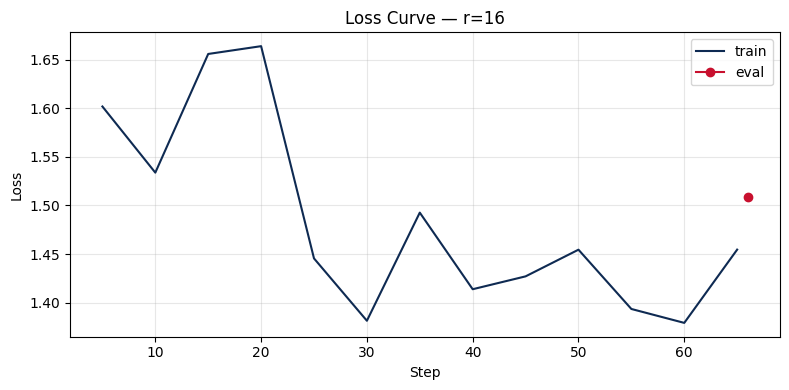

✓ Saved loss curve to ./outputs/loss_curve.png

📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Nếu không có eval curve thì đó là expected behaviour.


In [46]:
# Plot training loss and save loss_curve.png for submission
import pandas as pd

def plot_losses(log_history, title="Training Loss", save_path=None):
    df = pd.DataFrame(log_history)
    train = df[df["loss"].notna()] if "loss" in df else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df else pd.DataFrame()
    plt.figure(figsize=(8, 4))
    if not train.empty:
        plt.plot(train["step"], train["loss"], label="train", color="#0E2A52")
    if not eval_.empty:
        plt.plot(eval_["step"], eval_["eval_loss"], label="eval", color="#C8102E", marker="o")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()

loss_curve_path = os.path.join(OUTPUT_DIR, "loss_curve.png")
plot_losses(trainer_16.state.log_history, title="Loss Curve — r=16", save_path=loss_curve_path)
print(f"✓ Saved loss curve to {loss_curve_path}")
print("\n📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Nếu không có eval curve thì đó là expected behaviour.")


## 4. Rank Experiment — `r=8` vs `r=64`

Train 2 adapters thêm với rank khác để hiểu trade-off:
- **`r=8`** — chỉ ~0.05% params, train nhanh, ít VRAM
- **`r=64`** — ~0.4% params, gần full fine-tune, tốn VRAM hơn


In [47]:
def train_one_rank(r, alpha, variant_name=None, target_all=False, use_dora=False):
    """Train one adapter variant and return metrics for the summary table."""
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m = wrap_with_lora(base_m, r=r, alpha=alpha, target_all=target_all, use_dora=use_dora)
    trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)

    variant_name = variant_name or f"r{r}"
    tr = make_trainer(m, tok, train_ds, eval_ds, variant_name)
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    adapter_dir = os.path.join(ADAPTERS_DIR, variant_name)
    tr.model.save_pretrained(adapter_dir)
    print(f"✓ Saved adapter: {adapter_dir}")

    try:
        eval_loss = safe_evaluate(tr)
    except Exception as e:
        print(f"⚠ Eval failed for {variant_name}: {e}. Setting eval_loss=NaN.")
        eval_loss = float('nan')

    notes = []
    notes.append("all_layers" if target_all else "qv_only")
    if use_dora:
        notes.append("DoRA")

    return {
        "variant": variant_name,
        "rank": r,
        "alpha": alpha,
        "target_scope": "all_layers" if target_all else "qv_only",
        "use_dora": use_dora,
        "trainable_params": trainable_params,
        "train_time_min": wall / 60,
        "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)) if not np.isnan(eval_loss) else float("nan"),
        "notes": ",".join(notes),
        "trainer": tr,
        "model": m,
        "tokenizer": tok,
    }


In [48]:
# Cleanup baseline before training rank experiments
del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)


========== Training r=8 ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/173 [00:00<?, ? examples/s]

...

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 173 | Num Epochs = 3 | Total steps = 66
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 1,843,200 of 3,087,781,888 (0.06% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,1.603166
10,1.548985
15,1.682146
20,1.699700
25,1.480146
30,1.419464
35,1.523210
40,1.445492
45,1.460122
50,1.492139


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
✓ Saved adapter: ./outputs/adapters/r8


In [49]:
# Cleanup r=8 references
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)


========== Training r=64 ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/173 [00:00<?, ? examples/s]

...

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 173 | Num Epochs = 3 | Total steps = 66
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 14,745,600 of 3,100,684,288 (0.48% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,1.594928
10,1.487892
15,1.591931
20,1.590844
25,1.384653
30,1.306864
35,1.408569
40,1.326786
45,1.337987
50,1.344699


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
✓ Saved adapter: ./outputs/adapters/r64


In [50]:
# Cleanup r=64 references
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

stretch_results = []

if RUN_STRETCH_ALL_LAYERS:
    print("\n========== Stretch Goal: r=16 all layers ==========")
    try:
        exp_all_layers = train_one_rank(
            r=16,
            alpha=32,
            variant_name="r16_all_layers",
            target_all=True,
            use_dora=False,
        )
        stretch_results.append({
            k: v for k, v in exp_all_layers.items()
            if k not in ("trainer", "model", "tokenizer")
        })
        del exp_all_layers["trainer"], exp_all_layers["model"]
        gc.collect(); torch.cuda.empty_cache()
    except Exception as e:
        print(f"⚠ Skip all-layers stretch goal: {e}")

if RUN_STRETCH_DORA:
    print("\n========== Stretch Goal: r=16 DoRA ==========")
    try:
        exp_dora = train_one_rank(
            r=16,
            alpha=32,
            variant_name="r16_dora",
            target_all=False,
            use_dora=True,
        )
        stretch_results.append({
            k: v for k, v in exp_dora.items()
            if k not in ("trainer", "model", "tokenizer")
        })
        del exp_dora["trainer"], exp_dora["model"]
        gc.collect(); torch.cuda.empty_cache()
    except Exception as e:
        print(f"⚠ DoRA failed on this runtime, skipping stretch goal: {e}")
        print("ℹ T4 + Unsloth + xformers can hit mixed-dtype Q/K/V errors with DoRA.")

results = [
    {
        "variant": "base",
        "rank": np.nan,
        "alpha": np.nan,
        "target_scope": "base_model",
        "use_dora": False,
        "trainable_params": 0,
        "train_time_min": np.nan,
        "peak_vram_gb": np.nan,
        "eval_loss": base_eval_loss,
        "eval_perplexity": base_ppl,
        "notes": "reference_only",
    },
    {
        "variant": "r16",
        "rank": 16,
        "alpha": 32,
        "target_scope": "qv_only",
        "use_dora": False,
        "trainable_params": int(trainable),
        "train_time_min": wall_16 / 60,
        "peak_vram_gb": vram_16,
        "eval_loss": eval_loss_16,
        "eval_perplexity": ppl_16,
        "notes": "core_lab_baseline",
    },
    {k: v for k, v in exp_8.items() if k not in ("trainer", "model", "tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer", "model", "tokenizer")},
] + stretch_results

summary_df = pd.DataFrame(results)
summary_df = summary_df[
    [
        "variant",
        "rank",
        "alpha",
        "target_scope",
        "use_dora",
        "trainable_params",
        "train_time_min",
        "peak_vram_gb",
        "eval_loss",
        "eval_perplexity",
        "notes",
    ]
]

print("\n=== Rank / Stretch Experiment Summary ===")
print(summary_df.to_string(index=False))



========== Stretch Goal: r=16 all layers ==========
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/173 [00:00<?, ? examples/s]

...

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/20 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 173 | Num Epochs = 3 | Total steps = 66
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 3,769,344 of 3,089,708,032 (0.12% trained)


Unsloth: Will smartly offload gradients to save VRAM!
⚠ DoRA failed on this runtime, skipping stretch goal: Query/Key/Value should either all have the same dtype, or (in the quantized case) Key/Value should have dtype torch.int32
  query.dtype: torch.float32
  key.dtype  : torch.float16
  value.dtype: torch.float32
ℹ T4 + Unsloth + xformers can hit mixed-dtype Q/K/V errors with DoRA.

=== Rank / Stretch Experiment Summary ===
       variant  rank  alpha target_scope  use_dora  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity             notes
          base   NaN    NaN   base_model     False                 0             NaN           NaN   1.940261         6.960570    reference_only
           r16  16.0   32.0      qv_only     False           3686400        5.474725      7.867391   1.508781         4.521216 core_lab_baseline
            r8   8.0   16.0      qv_only     False           1843200        5.419228      8.471031   1.556760         4.743429         

## 5. Evaluation — Qualitative Comparison

Generate test prompts và so sánh fine-tuned vs base model trên 5 prompts (chạy full 20 nếu thời gian cho phép).

In [51]:
TEST_PROMPTS = [
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
    "Khi nào nên dùng RAG thay vì fine-tuning?",
    "Giải thích cách hoạt động của Flash Attention.",
    "List 3 câu hỏi phỏng vấn cho ML Engineer junior.",
    "Cho biết ưu điểm của Transformer so với RNN.",
    "Cách evaluate performance của một LLM fine-tuned model?",
]
print(f"✓ {len(TEST_PROMPTS)} test prompts")

✓ 10 test prompts


In [52]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=200):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

base_only_model, base_only_tok = load_base_model()
ft_base_model, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(ft_base_model, os.path.join(OUTPUT_DIR, "r16"))

qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS[:5]):
    print(f"\n━━━ Prompt {i+1}: {prompt[:80]}...")
    base_resp = generate_response(base_only_model, base_only_tok, prompt)
    ft_resp = generate_response(ft_model, tok_for_eval, prompt)
    qualitative_results.append(
        {
            "prompt": prompt,
            "base": base_resp[:300],
            "finetuned_r16": ft_resp[:300],
        }
    )
    print(f"  BASE: {base_resp[:200]}...")
    print(f"  FT  : {ft_resp[:200]}...")


==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


...

  BASE: 1. **Đối tượng mục tiêu**: UI/UX designer phải hiểu rõ đối tượng mục tiêu của sản phẩm và trải nghiệm người dùng. Đây là yếu tố đầu tiên để tạo ra thiết kế phù hợp và có hiệu quả.
2.舌1. **Chuẩn bị**: ...
  FT  : 1. Sự tương tác và trải nghiệm: Một UX/UI tốt là khi người dùng có thể dễ dàng tương tác với sản phẩm của bạn và cảm thấy như thể họ đang ở trong thế giới thực. 2. Hiệu quả: Một UX/UI tốt là khi người...

━━━ Prompt 4: Tóm tắt sự khác biệt giữa LoRA và QLoRA....


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: LoRA và QLoRA đều là các kỹ thuật cải thiện tính hiệu suất của mô hình NLP (Natural Language Processing). LoRA cải thiện tính hiệu suất của mô hình bằng cách bổ sung các tham số mới cho mô hình, trong...
  FT  : LoRA (Layer-wise Auto-Regressive Model) và QLoRA (Quantized LoRA) là hai cách tiếp cận khác nhau để cải thiện tính hiệu quả của mô hình NLP (NLP - Natural Language Processing). LoRA là một kỹ thuật để...

━━━ Prompt 5: Phân biệt prompt engineering, RAG, và fine-tuning....


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: Prompt engineering là phương pháp để cải thiện hiệu suất của các hệ thống AI bằng cách tạo ra các câu hỏi hoặc yêu cầu cụ thể để thu được thông tin chi tiết và liên quan đến vấn đề. Điều này giúp AI c...
  FT  : Prompt engineering, RAG, và fine-tuning là các kỹ thuật khác nhau để cải thiện hiệu suất của mô hình AI. Prompt engineering là quá trình thiết kế câu lệnh, hoặc "prompt", để giúp mô hình AI hiểu rõ hơ...


In [53]:
qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison.csv"), index=False)
print(qual_df.head())

                                              prompt  \
0  Giải thích khái niệm machine learning cho ngườ...   
1     Viết đoạn code Python tính số Fibonacci thứ n.   
2               Liệt kê 5 nguyên tắc thiết kế UI/UX.   
3           Tóm tắt sự khác biệt giữa LoRA và QLoRA.   
4  Phân biệt prompt engineering, RAG, và fine-tun...   

                                                base  \
0  Machine learning là một kỹ thuật trong trí tuệ...   
1  def fibonacci(n):\n    if n == 0:\n        ret...   
2  1. **Đối tượng mục tiêu**: UI/UX designer phải...   
3  LoRA và QLoRA đều là các kỹ thuật cải thiện tí...   
4  Prompt engineering là phương pháp để cải thiện...   

                                       finetuned_r16  
0  Machine learning là một phương pháp trong học ...  
1  Bài toán tính số Fibonacci thứ n thường được g...  
2  1. Sự tương tác và trải nghiệm: Một UX/UI tốt ...  
3  LoRA (Layer-wise Auto-Regressive Model) và QLo...  
4  Prompt engineering, RAG, và fine-tuning là các..

## 6. Bonus Tracking

Nếu bạn bật stretch goals, các cell tiếp theo sẽ lưu thêm:
- `bonus_summary.csv`
- `LINKS.md` cho Option B
- `requirements.txt` cho Option C
- metadata để viết phần bonus trong report dễ hơn


In [54]:
summary_df.to_csv(os.path.join(RESULTS_DIR, "rank_experiment_summary.csv"), index=False)
qual_df.to_csv(os.path.join(RESULTS_DIR, "qualitative_comparison.csv"), index=False)

bonus_df = summary_df[summary_df["variant"].isin(["r16_all_layers", "r16_dora"])].copy()
bonus_summary_path = os.path.join(RESULTS_DIR, "bonus_summary.csv")
bonus_df.to_csv(bonus_summary_path, index=False)

GPU_COST_USD_PER_HOUR = 0.35
rank_only_df = summary_df[summary_df["variant"] != "base"]
total_minutes = rank_only_df["train_time_min"].dropna().sum()
total_cost = (total_minutes / 60) * GPU_COST_USD_PER_HOUR

best_row = summary_df[
    summary_df["variant"] != "base"
].sort_values(["eval_perplexity", "train_time_min"], na_position="last").iloc[0]
BEST_VARIANT = best_row["variant"]
BEST_ADAPTER_DIR = os.path.join(ADAPTERS_DIR, BEST_VARIANT)

report_path = os.path.join(OUTPUT_DIR, "REPORT.md")
report_template = f"""# Lab 21 — Evaluation Report

**Học viên**: Nguyễn Xuân Hải - 2A202600245
**Ngày nộp**: 07-05-2026
**Submission option**: b

## 1. Setup
- **Base model**: `{MODEL_NAME}`
- **Dataset**: `{DATASET_ID}`, {len(ds)} cleaned samples ({len(train_ds)} train + {len(eval_ds)} eval)
- **max_seq_length**: {MAX_SEQ_LENGTH}
- **GPU**: {torch.cuda.get_device_name(0)}
- **Training cost**: ${total_cost:.2f} (~{total_minutes:.1f} phút @ ${GPU_COST_USD_PER_HOUR}/hr)
- **Best adapter candidate**: `{BEST_VARIANT}`
- **HF Hub link** (nếu Option B): https://huggingface.co/{HF_USERNAME}/<repo-name>

## 2. Rank Experiment Results
Điền bảng từ `outputs/results/rank_experiment_summary.csv`.

## 3. Loss Curve Analysis
Đính kèm `loss_curve.png` và phân tích dấu hiệu overfitting / underfitting.

## 4. Qualitative Comparison
Tóm tắt ít nhất 5 prompts từ `qualitative_comparison.csv`.

## 5. Conclusion về Rank Trade-off
Viết ít nhất 100 từ: rank nào có ROI tốt nhất, diminishing returns xảy ra ở đâu, và recommendation nếu deploy production.

## 6. What I Learned
- Reflection 1
- Reflection 2
- Reflection 3

## Optional Bonus Notes
- Stretch goal đã chạy: {', '.join(bonus_df['variant'].tolist()) if len(bonus_df) else 'None yet'}
- Best variant hiện tại: `{BEST_VARIANT}`
"""

if not os.path.exists(report_path):
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(report_template)
    print(f"✓ Created report template: {report_path}")
else:
    print(f"ℹ Existing report preserved: {report_path}")

print(f"✓ Saved rank summary: {os.path.join(RESULTS_DIR, 'rank_experiment_summary.csv')}")
print(f"✓ Saved qualitative comparison: {os.path.join(RESULTS_DIR, 'qualitative_comparison.csv')}")
print(f"✓ Saved bonus summary: {bonus_summary_path}")
print(f"✓ Current best adapter candidate: {BEST_VARIANT} -> {BEST_ADAPTER_DIR}")
print(f"✓ Total training time: {total_minutes:.1f} phút")
print(f"✓ Estimated cost: ${total_cost:.2f}")


✓ Created report template: ./outputs/REPORT.md
✓ Saved rank summary: ./outputs/results/rank_experiment_summary.csv
✓ Saved qualitative comparison: ./outputs/results/qualitative_comparison.csv
✓ Saved bonus summary: ./outputs/results/bonus_summary.csv
✓ Current best adapter candidate: r64 -> ./outputs/adapters/r64
✓ Total training time: 22.7 phút
✓ Estimated cost: $0.13


In [55]:
# Optional reproducibility artifact for Option C
if SAVE_REQUIREMENTS_TXT:
    requirements_path = os.path.join(OUTPUT_DIR, "requirements.txt")
    with open(requirements_path, "w", encoding="utf-8") as f:
        f.write("\n".join([
            "unsloth[colab-new]",
            "trl>=0.12,<0.16",
            "transformers",
            "datasets",
            "peft",
            "accelerate",
            "bitsandbytes",
            "matplotlib",
            "seaborn",
            "pandas",
        ]))
    print(f"✓ Saved requirements template: {requirements_path}")
else:
    print("Skipping requirements.txt export")


✓ Saved requirements template: ./outputs/requirements.txt


In [64]:
# Push best adapter to Hugging Face Hub (Option B)
from huggingface_hub import login
from peft import PeftModel
import os

HF_TOKEN = os.environ.get("HUGGINGFACE_HUB_TOKEN", "").strip()
if not HF_TOKEN:
    raise ValueError("Bạn chưa set HUGGINGFACE_HUB_TOKEN")

login(token=HF_TOKEN)

HUB_REPO_ID = f"{HF_USERNAME}/{EXPERIMENT_NAME}-{BEST_VARIANT}"
print(f"Pushing best adapter to Hub: {HUB_REPO_ID}")

hub_model, hub_tok = load_base_model()
best_model = PeftModel.from_pretrained(hub_model, BEST_ADAPTER_DIR)

best_model.push_to_hub(HUB_REPO_ID)
hub_tok.push_to_hub(HUB_REPO_ID)

hub_url = f"https://huggingface.co/{HUB_REPO_ID}"
print(f"✓ Adapter pushed: {hub_url}")


Pushing best adapter to Hub: nxhai/lab21_qwen25_3b_vi_t4-r64
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.
Unsloth: Restored added_tokens_decoder metadata in /tmp/tmp2ajfx8tp/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


✓ Adapter pushed: https://huggingface.co/nxhai/lab21_qwen25_3b_vi_t4-r64


In [65]:
# Optional: merge and export GGUF-style artifact (stretch goal)
if RUN_GGUF_EXPORT:
    try:
        gguf_dir = os.path.join(OUTPUT_DIR, "gguf_export")
        os.makedirs(gguf_dir, exist_ok=True)

        merge_model, merge_tok = load_base_model()
        from peft import PeftModel
        merged = PeftModel.from_pretrained(merge_model, BEST_ADAPTER_DIR)
        merged = merged.merge_and_unload()

        merged.save_pretrained(os.path.join(gguf_dir, "merged_model"))
        merge_tok.save_pretrained(os.path.join(gguf_dir, "merged_model"))
        print("✓ Merged model saved. Use llama.cpp conversion tooling in a follow-up step if needed.")
        print("ℹ Full GGUF conversion depends on llama.cpp tooling availability in the runtime.")
    except Exception as e:
        print(f"⚠ GGUF export path failed: {e}")
else:
    print("Skipping GGUF export")


Skipping GGUF export
